# Classification of UCI Wine Quality (Red + White) - Decision Tree

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Binary Classification of Wine Quality - Decision Tree vs Naive Bayes
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 2
- **Date:** July 2026

| Field | Value |
|---|---|
| Dataset | UCI Wine Quality - red + white combined (Cortez et al., 2009) |
| Task | Binary classification: low (quality < 6) vs high (quality >= 6) |
| Algorithm | Decision Tree (tuned, required) + Logistic Regression and Gaussian Naive Bayes comparators |
| Tuning | GridSearchCV, 5-fold cross-validation, scoring = ROC AUC |
| Evaluation | AUC-ROC curve, confusion matrix, precision / recall / F1 |
| Methodology | CRISP-DM |

This notebook follows the six CRISP-DM stages (Chapman et al., 2000) to classify a wine as **high** or **low**
quality from its physicochemical measurements. Assessment 1 modelled the quality score as
regression; this brief revisits the same data as **classification**, tuning a Decision
Tree judged primarily on the **AUC-ROC** curve. This final candidate removes exact duplicates before validation and retains a
generative **Gaussian Naive Bayes** model (Module 5) as a Bayesian contrast to the
discriminative tree.

> Quality is a subjective, ordinal score, so the classifier is framed as an
> **interpretable decision-support tool** that flags likely low-quality batches for human
> review, not a replacement for expert tasting.

---

## 1. Business Understanding

Wine producers and distributors want a fast, low-cost screen that flags batches likely to
score poorly with tasters, so limited expert time is spent where it matters. The
**business question** for this assessment is therefore: *can a wine be classified as high
or low quality from routine physicochemical lab measurements alone?*

The UCI Wine Quality dataset records 11 physicochemical traits (acidity, residual sugar,
alcohol, and so on) and an expert **quality** score from 0-10 for red and white *vinho verde*
wines (Cortez et al., 2009). Following the brief, the score is collapsed into a **binary
target**: **below 6 is "low" (class 1)**, **6 or above is "high" (class 0)**. Low is the
*positive* class because flagging weak batches is the action of interest.

Success is defined relative to a naive baseline that always predicts the majority class. A
useful model must beat that floor and, more importantly, achieve a high **AUC-ROC** - the
chance it ranks a random low-quality wine above a random high-quality one - since AUC is
threshold-independent and robust to class imbalance. The output supports, but does not
replace, human quality control.

## 2. Data Understanding

This stage acquires the data, checks its quality, and explores how the physicochemical
features relate to wine quality.

### 2.1 Data acquisition

| Item | Detail |
|---|---|
| Source | UCI Machine Learning Repository - Wine Quality (id 186) |
| Dataset link | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Files | `winequality-red.csv` and `winequality-white.csv` |
| Acquisition | Local CSV copies downloaded from UCI; the loader retains a direct-URL fallback |
| Separator | Semicolon (`;`) |
| Raw rows | 1,599 red + 4,898 white = 6,497 |

The two files describe Portuguese *vinho verde* samples and can support classification or
regression (Cortez et al., 2009; University of California, Irvine, n.d.). They are combined
with a `wine_type` indicator (1 = red, 0 = white).

### 2.2 Variable description

| Variable | Role | Type | Meaning / unit |
|---|---|---|---|
| fixed acidity | Feature | Continuous | Non-volatile acids (g/dm3) |
| volatile acidity | Feature | Continuous | Acetic acid (g/dm3) |
| citric acid | Feature | Continuous | Citric acid (g/dm3) |
| residual sugar | Feature | Continuous | Sugar after fermentation (g/dm3) |
| chlorides | Feature | Continuous | Salt content (g/dm3) |
| free sulfur dioxide | Feature | Continuous | Free SO2 (mg/dm3) |
| total sulfur dioxide | Feature | Continuous | Total SO2 (mg/dm3) |
| density | Feature | Continuous | Density (g/cm3) |
| pH | Feature | Continuous | Acidity/basicity (pH scale) |
| sulphates | Feature | Continuous | Potassium sulphate (g/dm3) |
| alcohol | Feature | Continuous | Alcohol (% by volume) |
| wine_type | Engineered feature | Binary | White = 0, red = 1 |
| quality | Source target | Ordinal integer | Expert sensory score (0-10) |
| quality_label | Model target | Binary | High (>=6) = 0, low (<6) = 1 |

In [1]:
import os
import warnings

# Silence sklearn/joblib parallel UserWarnings so they cannot flood the exported
# PDF. n_jobs=1 in the grid search below means no worker processes spawn either.
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
from pathlib import Path

# Resolve project folders relative to the notebook location so the same notebook
# runs locally and on Colab/Azure without editing paths.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_BASE = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/")


def load_wine(colour):
    fname = f"winequality-{colour}.csv"
    candidates = [BASE_DIR / "dataset" / fname,
                  NB_DIR / "dataset" / fname,
                  NB_DIR / fname]
    local = next((p for p in candidates if p.exists()), None)
    if local is not None:
        print("Loading local:", local)
        return pd.read_csv(local, sep=";")
    print("Loading from UCI URL:", UCI_BASE + fname)
    return pd.read_csv(UCI_BASE + fname, sep=";")


red = load_wine("red")
white = load_wine("white")
red["wine_type"] = 1    # 1 = red
white["wine_type"] = 0  # 0 = white
df = pd.concat([red, white], ignore_index=True)

print("Red:", red.shape, "| White:", white.shape, "| Combined:", df.shape)
df.head()

Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment2/dataset/winequality-red.csv
Loading local: /Users/luisfaria/Desktop/sEngineer/masters_SWEAI/2026-T2/MLN/assignments/Assessment2/dataset/winequality-white.csv
Red: (1599, 13) | White: (4898, 13) | Combined: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nRaw rows:", len(df))
print("Exact duplicate rows:", int(df.duplicated().sum()))

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0

Raw rows: 6497
Exact duplicate rows: 1177


### 2.3 The classification target

The brief defines the target by thresholding the expert score: **quality < 6 -> "low" (1)**
and **quality >= 6 -> "high" (0)**. Encoding low quality as the positive class (1) keeps
the model's "positive" prediction aligned with the business action - flagging a batch for
review. Before deriving the target, the cell below removes exact duplicate records so an
identical wine cannot appear in both training and test data. It then derives the
`quality_label` column and shows the class balance. The
split is uneven (more high-quality wines), which is why **accuracy alone is misleading** and evaluation leans on AUC-ROC and
per-class recall.

Raw rows: 6497 | duplicates removed: 1177 | unique rows: 5320

Class counts:
quality_label
high (>=6)    3332
low (<6)      1988

Class proportions:
quality_label
high (>=6)    0.626
low (<6)      0.374


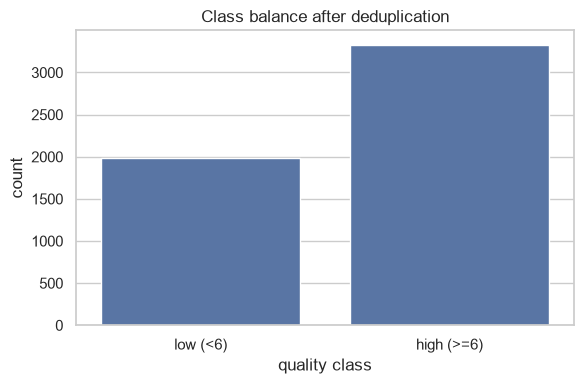

In [6]:
# Remove exact source-record duplicates before target engineering or splitting.
raw_rows = len(df)
duplicate_rows = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Raw rows:", raw_rows,
      "| duplicates removed:", duplicate_rows,
      "| unique rows:", len(df))

# Brief's encoding: quality < 6 -> low (1, positive class); quality >= 6 -> high (0)
df["quality_label"] = (df["quality"] < 6).astype(int)
label_names = {0: "high (>=6)", 1: "low (<6)"}
df["quality_name"] = df["quality_label"].map(label_names)

counts = df["quality_label"].value_counts().sort_index()
print("\nClass counts:")
print(counts.rename(index=label_names).to_string())
print("\nClass proportions:")
print((counts / len(df)).round(3).rename(index=label_names).to_string())

plt.figure(figsize=(6, 4))
sns.countplot(x="quality_name", data=df, order=["low (<6)", "high (>=6)"])
plt.title("Class balance after deduplication")
plt.xlabel("quality class")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_class_balance.png", dpi=120)
plt.show()

### 2.4 Feature relationships

The correlation heatmap and the seaborn **pairplot** (required by the brief) show how the
features move with each other and with quality. `alcohol` shows the clearest separation
between high and low wines, while several acidity and sulfur-dioxide measures are
correlated with each other - a hint that a non-linear model able to capture interactions
may do well.

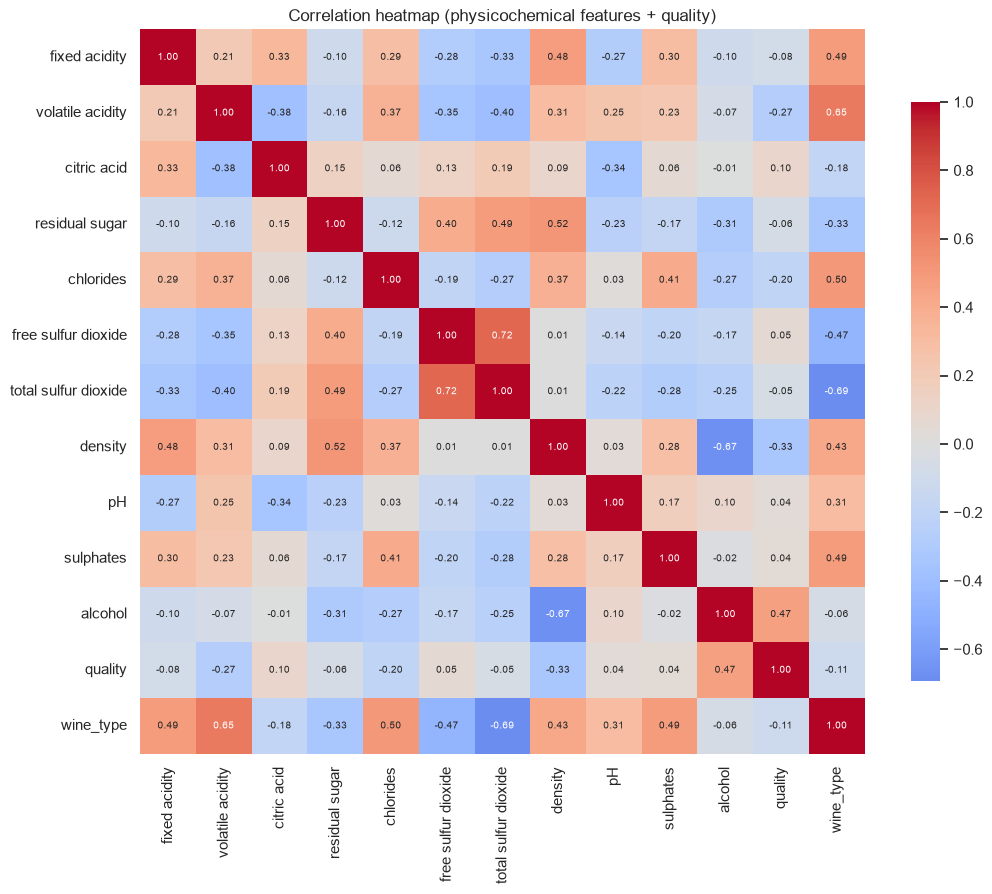

In [7]:
plt.figure(figsize=(11, 9))
corr = df.drop(columns=["quality_label"]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation heatmap (physicochemical features + quality)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_corr_heatmap.png", dpi=120)
plt.show()

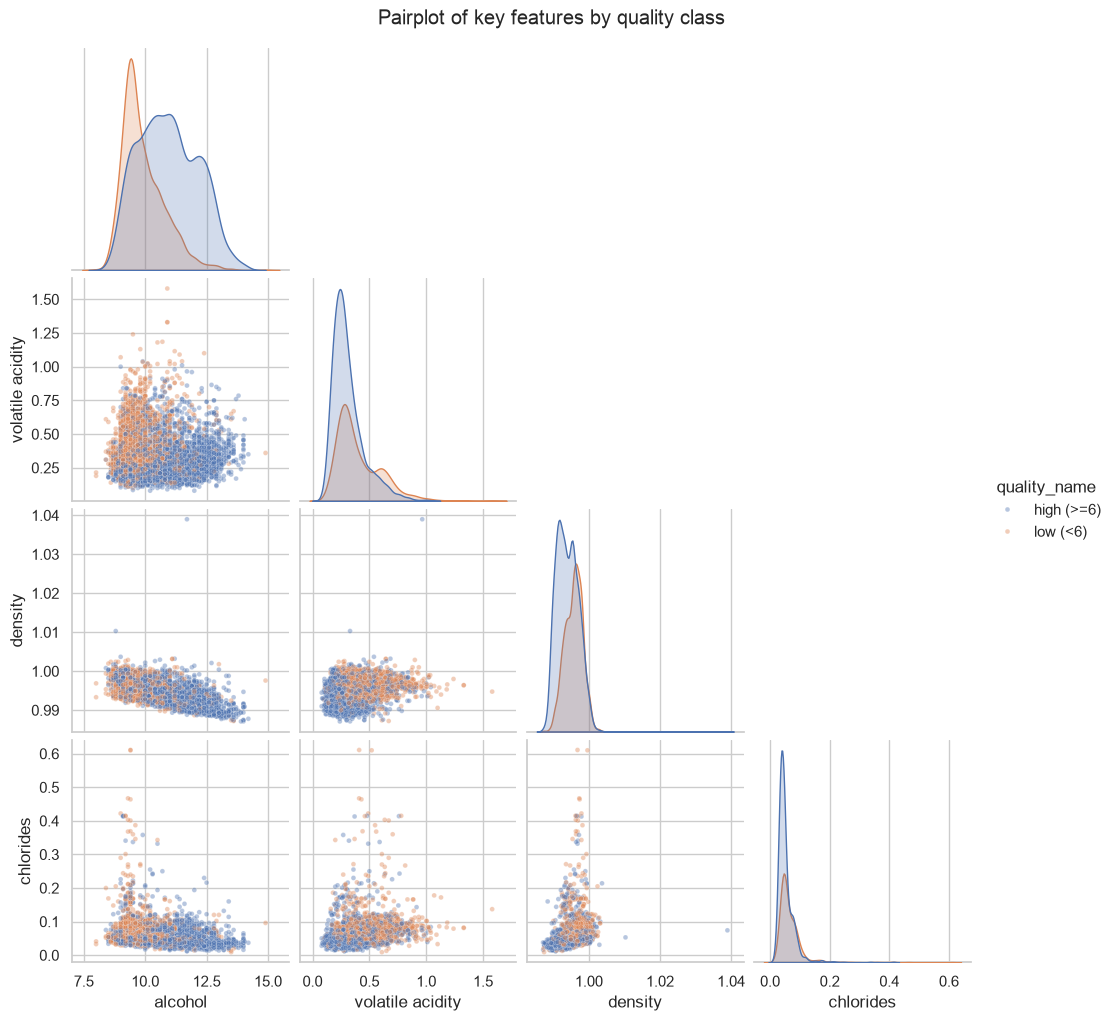

In [8]:
pair_cols = ["alcohol", "volatile acidity", "density", "chlorides"]
g = sns.pairplot(df, vars=pair_cols, hue="quality_name",
                 hue_order=["high (>=6)", "low (<6)"], corner=True,
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde")
g.fig.suptitle("Pairplot of key features by quality class", y=1.02)
g.savefig(FIG_DIR / "v3_pairplot.png", dpi=110)
plt.show()

**Interpretation:** Three things stand out:

- There are **no missing values**, so no imputation is needed; 1,177 exact duplicates are
  removed before modelling to protect the held-out test set.
- `alcohol` has the strongest positive association with high quality, while `volatile
  acidity` has the clearest negative one.
- Several features are mutually correlated, including the two sulfur-dioxide measures and
  `density` with `alcohol` and `residual sugar`.

Collinearity can destabilise a linear model's coefficients but affects a Decision Tree less
because it splits one feature at a time. The pairplot also shows substantial class overlap,
so a useful but imperfect classifier is more realistic than near-perfect separation.

## 3. Data Preparation

Preparation is light but deliberate. **(1) Deduplication:** 1,177 exact records are removed
before target engineering and splitting. In the previous draft, a random split placed 359
test rows (27.6%) as exact copies of training rows; removing duplicates restores a genuinely
unseen test set. **(2) Feature/target split:** `quality` and derived label columns are removed
from `X`, preventing direct target leakage; `wine_type` remains a feature. **(3) Train/test
split:** an 80/20 **stratified** split preserves the class ratio, with `random_state=42` for
reproducibility. **(4) Scaling:** the Decision Tree and Gaussian Naive Bayes use the original
units. Logistic Regression requires scaling, so `StandardScaler` sits **inside a Pipeline**
and is refit only on training data during cross-validation (Pedregosa et al., 2011).

In [9]:
LEAK_COLS = ["quality", "quality_label", "quality_name"]
feature_cols = [c for c in df.columns if c not in LEAK_COLS]
X = df[feature_cols]
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Exact feature rows must not cross the train/test boundary after deduplication.
train_keys = pd.MultiIndex.from_frame(X_train)
test_keys = pd.MultiIndex.from_frame(X_test)
overlap_count = int(test_keys.isin(train_keys).sum())
assert overlap_count == 0, "Exact feature rows leaked across train/test split"

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Exact train/test feature overlap:", overlap_count)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3).rename(index=label_names).to_string())
print("\nFeatures used (%d):" % len(feature_cols), feature_cols)

Train: (4256, 12) | Test: (1064, 12)
Exact train/test feature overlap: 0

Train class balance:
quality_label
high (>=6)    0.626
low (<6)      0.374
Test class balance:
quality_label
high (>=6)    0.626
low (<6)      0.374

Features used (12): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'wine_type']


## 4. Modelling

Five models are compared so the tuned Decision Tree can be read against both a
*discriminative* and a *generative* alternative:

1. **Majority-class baseline** (`DummyClassifier`) - the floor every real model must beat;
   its AUC sits at ~0.5 by construction.
2. **Default Decision Tree** - an untuned tree, to show what tuning actually buys.
3. **Tuned Decision Tree** - the required model. Using scikit-learn (Pedregosa et al., 2011), `GridSearchCV` searches `max_depth`,
   `min_samples_leaf`, `criterion` (gini vs entropy) and `class_weight` (none vs balanced)
   using **5-fold cross-validation**, scored on **ROC AUC**. An unconstrained tree grows
   until its leaves are pure and overfits; these hyperparameters prune that complexity.
4. **Logistic Regression** - a linear probabilistic comparator (Module 8). The brief asks
   for one technique, so this is included only as **optional context**: a straight-line
   decision boundary to contrast with the tree's axis-aligned splits.
5. **Gaussian Naive Bayes** - a *generative* comparator (Module 5's Bayes rule). Where the
   others learn the boundary directly, it models each feature's distribution per class and
   inverts it with Bayes' theorem - a different philosophy on the same data.

Every estimator uses a fixed seed and `n_jobs=1`. Cross-validation tunes on the training set
only; the test set is touched once, in Evaluation.

In [10]:
# 1) Majority-class baseline
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

# 2) Default (untuned) Decision Tree
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# 3) Tuned Decision Tree - the required model
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid, scoring="roc_auc", cv=5, n_jobs=1)
grid.fit(X_train, y_train)
dt_best = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV ROC AUC: %.3f" % grid.best_score_)

# 4) Logistic Regression comparator (needs scaling -> Pipeline)
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

# 5) Gaussian Naive Bayes - generative comparator (Module 5, Bayes rule)
nb = GaussianNB()
nb.fit(X_train, y_train)

models = {
    "Majority baseline": dummy,
    "Decision Tree (default)": dt_default,
    "Decision Tree (tuned)": dt_best,
    "Logistic Regression": logreg,
    "Naive Bayes (Gaussian)": nb,
}
print("\nFitted models:", list(models))

Best params: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20}
Best CV ROC AUC: 0.791

Fitted models: ['Majority baseline', 'Decision Tree (default)', 'Decision Tree (tuned)', 'Logistic Regression', 'Naive Bayes (Gaussian)']


### 4.2 Selected hyperparameters

`GridSearchCV` refits the best configuration on the full training set. The chosen parameters
balance depth against generalisation - a moderate `max_depth` with a leaf size large enough to
stop the tree memorising individual wines. Saved to `outputs/` for traceability.

In [11]:
best_params = pd.Series(grid.best_params_, dtype="object").astype(str)
best_params.loc["cv_roc_auc"] = round(grid.best_score_, 4)
best_params.to_csv(OUTPUT_DIR / "tree_best_params_v3.csv", header=["value"])
best_params.to_frame("value")

,value
class_weight,NaN
criterion,gini
max_depth,5
min_samples_leaf,20
cv_roc_auc,0.791


## 5. Evaluation

The models are now judged on the **held-out test set** they never saw during tuning.
Because the classes are imbalanced, no single number tells the whole story, so several
complementary metrics are reported:

- **AUC-ROC** - the headline metric: how well the model *ranks* low-quality wines above
  high-quality ones across all thresholds, and is less sensitive to class proportions than raw accuracy.
- **Accuracy** - intuitive but misleading here: always predicting "high" already scores 63%,
  so it must be read against the baseline.
- **Precision, recall and F1 for the low class** - whether the model actually *catches* the
  weak batches, and how often its flags are correct.
- **Confusion matrix** - the raw counts behind those rates.

The ROC curves are overlaid (diagonal = random guessing); the tree plot and feature-importance
chart keep the model's logic transparent - a white-box advantage.

**Plain-English reading:** an AUC of 0.80 means that, across many random pairs,
the model assigns the low-quality wine a higher risk score than the high-quality wine
about 80% of the time. The confusion matrix instead describes one chosen threshold.

In [12]:
def class_metrics(model, X_te, y_te):
    pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]   # P(class 1 = low)
    else:
        proba = model.decision_function(X_te)
    pos = dict(pos_label=1, zero_division=0)
    return {
        "accuracy": accuracy_score(y_te, pred),
        "precision_low": precision_score(y_te, pred, **pos),
        "recall_low": recall_score(y_te, pred, **pos),
        "f1_low": f1_score(y_te, pred, **pos),
        "roc_auc": roc_auc_score(y_te, proba),
    }

results = pd.DataFrame(
    {name: class_metrics(m, X_test, y_test) for name, m in models.items()}
).T.round(3)
results.index.name = "model"
results.to_csv(OUTPUT_DIR / "model_metrics_v3.csv")
results

,accuracy,precision_low,recall_low,f1_low,roc_auc
model,,,,,
Majority baseline,0.626,0.000,0.000,0.000,0.500
Decision Tree (default),0.682,0.579,0.555,0.567,0.657
Decision Tree (tuned),0.739,0.672,0.588,0.627,0.793
Logistic Regression,0.744,0.706,0.543,0.614,0.813
Naive Bayes (Gaussian),0.671,0.579,0.442,0.501,0.736


In [13]:
report = classification_report(
    y_test, dt_best.predict(X_test),
    target_names=["high (>=6)", "low (<6)"],
    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(3)
report_df.to_csv(OUTPUT_DIR / "classification_report_v3.csv")
report_df

,precision,recall,f1-score,support
high (>=6),0.771,0.829,0.799,666.000
low (<6),0.672,0.588,0.627,398.000
accuracy,0.739,0.739,0.739,0.739
macro avg,0.722,0.708,0.713,1064.000
weighted avg,0.734,0.739,0.735,1064.000


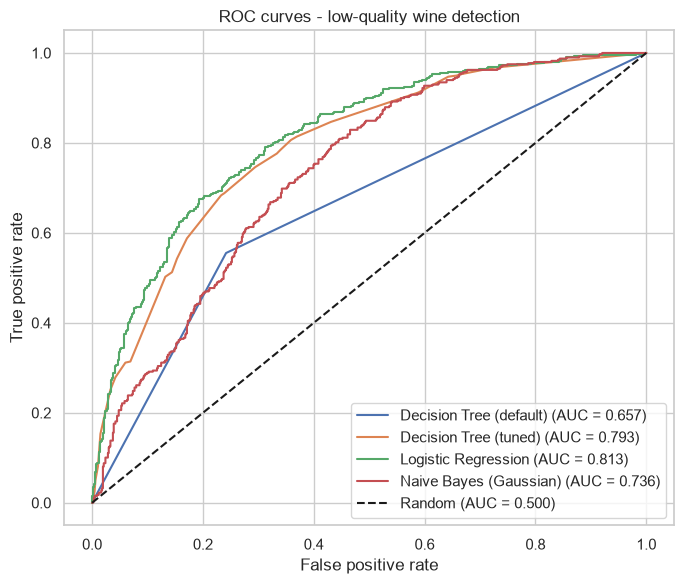

In [14]:
plt.figure(figsize=(7, 6))
for name, m in models.items():
    if name == "Majority baseline":
        continue
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba, pos_label=1)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves - low-quality wine detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_roc_curves.png", dpi=120)
plt.show()

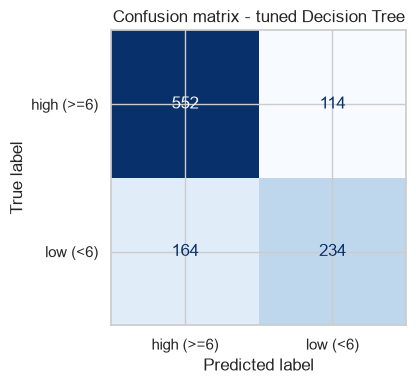

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, dt_best.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["high (>=6)", "low (<6)"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix - tuned Decision Tree")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_confusion_matrix.png", dpi=120)
plt.show()

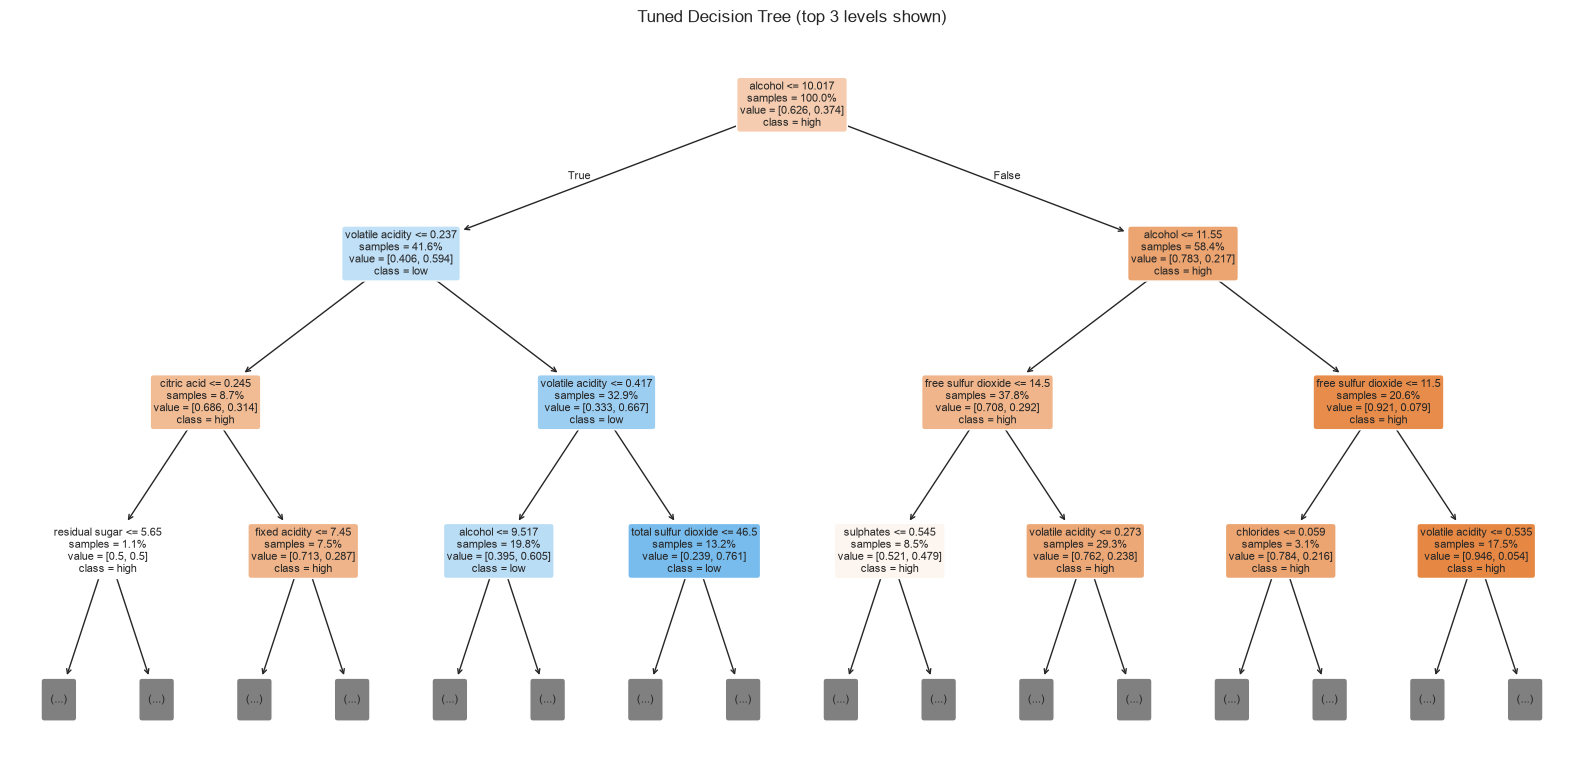

In [16]:
plt.figure(figsize=(16, 8))
plot_tree(dt_best, feature_names=feature_cols, class_names=["high", "low"],
          filled=True, rounded=True, max_depth=3, fontsize=8,
          impurity=False, proportion=True)
plt.title("Tuned Decision Tree (top 3 levels shown)")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_decision_tree.png", dpi=110)
plt.show()

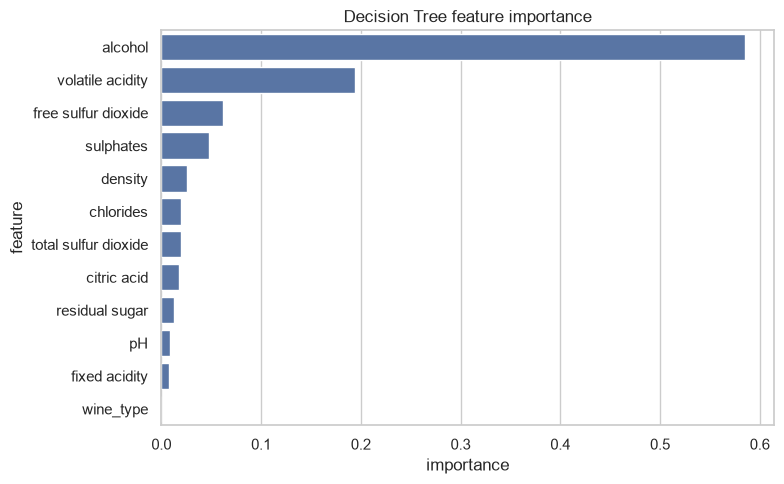

,feature,importance
0,alcohol,0.584984
1,volatile acidity,0.194089
2,free sulfur dioxide,0.062024
3,sulphates,0.048053
4,density,0.025319
5,chlorides,0.019837
6,total sulfur dioxide,0.019447
7,citric acid,0.017371
8,residual sugar,0.012549
9,pH,0.008293


In [17]:
importance = (pd.DataFrame({"feature": feature_cols,
                            "importance": dt_best.feature_importances_})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True))
importance.to_csv(OUTPUT_DIR / "feature_importance_v3.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance", y="feature", data=importance)
plt.title("Decision Tree feature importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "v3_feature_importance.png", dpi=120)
plt.show()
importance

The tuned Decision Tree reaches a test **AUC of 0.793**, comfortably above the majority
baseline (0.500) and the untuned tree (0.657), while Logistic Regression remains the
strongest comparator at 0.813. Tuning improves both ranking and accuracy: pruning to
`max_depth=5` and `min_samples_leaf=20` raises AUC from 0.657 to 0.793 and accuracy from
0.68 to 0.74. Removing duplicates also lowers the tree's earlier draft AUC from 0.809 to
0.793, confirming that duplicate overlap had made validation modestly optimistic.

The confusion matrix shows stronger recall for high-quality wines (0.83) than low-quality
wines (0.59), so the model still misses some batches it is meant to flag. Feature importance
is dominated by `alcohol` (0.58) and `volatile acidity` (0.19), while `wine_type` adds almost
nothing. The initial objective is met: the required tree provides useful ranking and clear
rules, but should remain decision support rather than an automatic rejection mechanism.

### 5.4 Generative vs discriminative: where Naive Bayes lands

The Decision Tree and Logistic Regression are **discriminative**: they model the boundary
P(class | features). **Gaussian Naive Bayes** is **generative**: it estimates each feature's
distribution per class and combines those distributions with Bayes' rule. Its conditional-
independence assumption is violated here because several features are correlated. Domingos
and Pazzani (1997) nevertheless show that Naive Bayes classification can remain effective
under substantial dependence violations.

Here, Naive Bayes reaches an AUC of **0.736**. It ranks better than the untuned tree (0.657)
but remains behind the tuned tree (0.793) and Logistic Regression (0.813). This supports a
careful conclusion: the model retains useful classification signal despite the violated
assumption, but the discriminative models fit this dataset better.

## 6. Deployment / Lessons Learned

For this assessment, deployment means reflection rather than a production release.

**What worked:** binary framing made the Decision Tree a natural, interpretable model, and
AUC-ROC evaluated ranking across thresholds where accuracy alone could flatter an "always
high" prediction. Deduplicating before splitting also restored a genuinely unseen test set;
the modest AUC reduction from 0.809 to 0.793 is a more credible result, not a failure.

**What was harder:** the classes overlap heavily, and low-quality recall remains weaker
(0.59 versus 0.83 for high quality). Grid search explored class weighting but selected a
shallow unweighted tree (`max_depth=5`, `min_samples_leaf=20`) as the best AUC trade-off.
Naive Bayes also showed how a useful model can survive a violated assumption without becoming
the best choice.

**Next steps:** test Random Forest or gradient boosting; tune the classification threshold to
the real cost of missing a poor batch; and validate on wine collected from a different time
or producer. The main lesson is that preprocessing and evaluation design can change the
credibility of a result as much as model selection itself.

---

## Academic Integrity Declaration

I declare that except where I have referenced, the work I am submitting for this assessment task is my own work. I have read and am aware of the Torrens University Australia Academic Integrity Policy and Procedure viewable online at http://www.torrens.edu.au/policies-and-forms

I am aware that I need to keep a copy of all submitted material and their drafts, and I will do so accordingly.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this report:
- Anthropic Claude Opus 4.8
- OpenAI ChatGPT Codex 5.5

Both tools were used to assist with understanding ML concepts, structuring the technical pipeline, improving clarity of academic language, and supporting APA 7th referencing conventions.

Prompt examples:
1. "Explain how to convert the UCI wine quality score into a binary classification target and why AUC-ROC is the right metric when the classes are imbalanced."
2. "How do I tune a scikit-learn DecisionTreeClassifier with GridSearchCV (max_depth, min_samples_leaf, criterion, class_weight) using 5-fold cross-validation scored on ROC AUC, without leaking the test set?"
3. "Why is a Decision Tree scale-invariant while Logistic Regression needs a StandardScaler, and how should I place the scaler in a Pipeline to avoid data leakage during cross-validation?"

I confirm that the use of these tools has been in accordance with the Torrens University Australia Academic Integrity Policy and TUA, Think and MDS's Position Paper on the Use of AI. I confirm that the final output is authored by me and represents my own critical thinking, analysis, and synthesis of sources. I take full responsibility for the final content of this report.

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Domingos, P., & Pazzani, M. (1997). On the optimality of the simple Bayesian classifier under zero-one loss. *Machine Learning, 29*(2-3), 103-130. https://doi.org/10.1023/A:1007413511361

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

University of California, Irvine. (n.d.). *Wine Quality* [Data set]. UCI Machine Learning Repository. Retrieved July 2, 2026, from https://archive.ics.uci.edu/dataset/186/wine+quality